In [2]:
import torch
import torch.nn as nn
import torch.autograd as autograd
import numpy as np
from torch.linalg import eigvalsh
import pandas as pd
import copy
import matplotlib.pyplot as plt
from scipy.linalg import eigvals as scipy_eigvals



num_iter = 10000

torch.backends.cudnn.enabled = False
dtype = torch.float64
torch.set_default_dtype(dtype)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
print("Using device: ", device)

# Parameters

Nc = 3
g5_sq = (12*np.pi**2)/Nc

omega_a1 = torch.tensor([1.23, 1.655], device=device)  # in GeV
omega_a2 = torch.tensor([1.3182, 1.706], device=device)  # in GeV
omega_rho = torch.tensor([0.77526, 1.465, 1.72], device=device)
omega_f0 = torch.tensor([0.475, 0.99, torch.nan, 1.522, 1.733, 1.982], device=device)  # in GeV
omega_pi = torch.tensor([0.135, 1.3, 1.8], device=device)  # in GeV

z_max = 15.0
h = 0.15
z_ini = h

def V_k_fn(v_z, k1, k2):
    return (k2)*v_z**3 + k1*v_z**2

fpi_sq = (92.4e-3)**2  # in GeV^2
mpi_sq = (139.57e-3)**2  # in GeV^2

zeta = np.sqrt(Nc)/(2*np.pi)

def Sigma_fn(theta, scale=1):
    return 0.01 + (0.03 - 0.01)*torch.sigmoid(theta*scale)

def ab_fn(theta, L):
    Sigma = Sigma_fn(theta)
    m_q = fpi_sq*mpi_sq/(2*Sigma)
    alpha = zeta*m_q*L
    beta = (Sigma/zeta)*(L**3)

    return alpha, beta

# DEFINE A(z) THE NEURAL NETWORK
n_neurons = [50, 50, 50, 50]

class A_LinearNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        layers = []
        activation_fn = nn.SiLU()
        layers.append(nn.Linear(1, n_neurons[0])) # input layer
        layers.append(activation_fn)
        for i in range(len(n_neurons) - 1):
            layers.append(nn.Linear(n_neurons[i], n_neurons[i + 1]))
            layers.append(activation_fn)
        layers.append(nn.Linear(n_neurons[-1], 1)) # output layer
        self.network = nn.Sequential(*layers)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        # scale z from [0, z_max] to [-1, 1]
        #z = 2.0 * (z) / (z_max) - 1.0

        # scale z from [0, z_max] to [0, 1]
        z = z / z_max
        input = z.reshape(-1, 1)
        return self.network(input).squeeze()


# DEFINE v(z)THE NEURAL NETWORK
#n_neurons = [20, 20, 20, 20] # number of neurons in each hidden layer

class v_LinearNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        layers = []
        activation_fn = nn.SiLU()
        layers.append(nn.Linear(1, n_neurons[0])) # input layer
        layers.append(activation_fn)
        for i in range(len(n_neurons) - 1):
            layers.append(nn.Linear(n_neurons[i], n_neurons[i + 1]))
            layers.append(activation_fn)
        layers.append(nn.Linear(n_neurons[-1], 1)) # output layer
        self.network = nn.Sequential(*layers)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        # scale z from [0, z_max] to [0, 1]
        z = z / z_max
        input = z.reshape(-1, 1)
        return self.network(input).squeeze()
    
def weights_init(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
        #torch.nn.init.xavier_normal_(m.weight)

def v_z_fn(z, model_v, theta, L):
    alpha, beta = ab_fn(theta, L)
    return (alpha*z + beta*z**3 + model_v(z)*z**4)/(1+z**3)

def A_z_fn(z, model_A):
    return -torch.log(z) + z*model_A(z)*0.1

def B2_dash_z_fn(exp_2A_z, v_z, dv_dz, d2v_dz2, k1, k2):
    return (d2v_dz2 - exp_2A_z*(-3*v_z - V_k_fn(v_z, k1, k2)))/dv_dz


def V_mesons(model_A, model_v,  k1, k2, theta, L, z=None):
    if z is None:
        z = torch.arange(z_ini, z_max, h, device=device, requires_grad=True)

    A_z = A_z_fn(z, model_A)
    exp_2A = torch.exp(2*A_z)
    dA_dz = autograd.grad(A_z, z, torch.ones_like(A_z), create_graph=True)[0]
    d2A_dz2 = autograd.grad(dA_dz, z, torch.ones_like(dA_dz), create_graph=True)[0]

    v_z = v_z_fn(z, model_v, theta, L)
    dv_dz = autograd.grad(v_z, z, torch.ones_like(v_z), create_graph=True)[0]
    d2v_dz2 = autograd.grad(dv_dz, z, torch.ones_like(dv_dz), create_graph=True)[0]
    
    dB2_dz = B2_dash_z_fn(exp_2A, v_z, dv_dz, d2v_dz2,  k1, k2)
    dB1_dz = dB2_dz + 2*dA_dz

    d2B2_dz2 = autograd.grad(dB2_dz, z, torch.ones_like(dB2_dz), create_graph=True)[0]
    d2B1_dz2 = d2B2_dz2 + 2*d2A_dz2

    V_rho = 0.25*dB1_dz**2 - 0.5*d2B1_dz2
    V_a1 = V_rho + g5_sq*exp_2A*v_z**2
    V_a2 = 0.25*dB2_dz**2 - 0.5*d2B2_dz2
    V_f0 = V_a2 + exp_2A*(-3 - (2*k1*v_z + 3*(k2)*v_z**2)) 

    return V_rho, V_a1, V_a2, V_f0

def eigenvalues_square_fn(model_A, model_v,  k1, k2, theta, L, no_eigenvalues = (2, 2, 2, 2)):
    V_rho, V_a1, V_a2, V_f0 = V_mesons(model_A, model_v,  k1, k2, theta, L)
    diag_elem_rho = 2 + V_rho*h**2
    diag_elem_a1 = 2 + V_a1*h**2
    diag_elem_a2 = 2 + V_a2*h**2
    diag_elem_f0 = 2 + V_f0*h**2

    off_diag_elem = -1 * torch.ones_like(diag_elem_rho[:-1])

    mat_rho = (torch.diag(diag_elem_rho) + torch.diag(off_diag_elem, diagonal=1) + torch.diag(off_diag_elem, diagonal=-1))/h**2
    mat_a1 = (torch.diag(diag_elem_a1) + torch.diag(off_diag_elem, diagonal=1) + torch.diag(off_diag_elem, diagonal=-1))/h**2
    mat_a2 = (torch.diag(diag_elem_a2) + torch.diag(off_diag_elem, diagonal=1) + torch.diag(off_diag_elem, diagonal=-1))/h**2
    mat_f0 = (torch.diag(diag_elem_f0) + torch.diag(off_diag_elem, diagonal=1) + torch.diag(off_diag_elem, diagonal=-1))/h**2

    eigenvalues_rho = eigvalsh(mat_rho)[:no_eigenvalues[0]]/(L**2)
    eigenvalues_a1 = eigvalsh(mat_a1)[:no_eigenvalues[1]]/(L**2)
    eigenvalues_a2 = eigvalsh(mat_a2)[:no_eigenvalues[2]]/(L**2)
    eigenvalues_f0 = eigvalsh(mat_f0)[:no_eigenvalues[3]]/(L**2)

    return eigenvalues_rho, eigenvalues_a1, eigenvalues_a2, eigenvalues_f0

################################################################################################################################
################################################ Loss Functions ################################################################
################################################################################################################################

# Mass loss
def mass_loss_fn(model_A, model_v,  k1, k2, theta, L, train_data=(omega_rho, omega_a1, omega_a2, omega_f0)):
    omega_rho, omega_a1, omega_a2, omega_f0 = train_data

    mbyL_rho, mbyL_a1, mbyL_a2, mbyL_f0 = eigenvalues_square_fn(model_A, model_v, k1, k2, theta, L, (len(omega_rho), len(omega_a1), len(omega_a2), len(omega_f0)))
    
    # remove None values from omega_f0, omega_rho, omega_a1, omega_a2 and corresponding mbyL_f0, mbyL_rho, mbyL_a1, mbyL_a2 values
    mask_f0 = ~torch.isnan(omega_f0)
    mask_rho = ~torch.isnan(omega_rho)
    mask_a1 = ~torch.isnan(omega_a1)
    mask_a2 = ~torch.isnan(omega_a2)


    omega_f0 = omega_f0[mask_f0]
    omega_rho = omega_rho[mask_rho]
    omega_a1 = omega_a1[mask_a1]
    omega_a2 = omega_a2[mask_a2]

    mbyL_f0 = mbyL_f0[mask_f0]
    mbyL_rho = mbyL_rho[mask_rho]
    mbyL_a1 = mbyL_a1[mask_a1]
    mbyL_a2 = mbyL_a2[mask_a2]

    rho_mass_loss = torch.abs(mbyL_rho - omega_rho**2)/omega_rho**2
    a1_mass_loss = torch.abs(mbyL_a1 - omega_a1**2)/omega_a1**2
    a2_mass_loss = torch.abs(mbyL_a2 - omega_a2**2)/omega_a2**2
    f0_mass_loss = torch.abs(mbyL_f0 - omega_f0**2)/omega_f0**2

    f0_mass_loss[0] *= 0.1 # give less weight to the lightest f0 meson since its nature is not well established

    sum_loss = (rho_mass_loss.sum() + a1_mass_loss.sum() + a2_mass_loss.sum() + f0_mass_loss.sum()).detach()

    rho_scaling = rho_mass_loss.detach()/sum_loss
    a1_scaling = a1_mass_loss.detach()/sum_loss
    a2_scaling = a2_mass_loss.detach()/sum_loss
    f0_scaling = f0_mass_loss.detach()/sum_loss

    rho_mass_loss = (rho_mass_loss * rho_scaling).mean()
    a1_mass_loss = (a1_mass_loss * a1_scaling).mean()
    a2_mass_loss = (a2_mass_loss * a2_scaling).mean()
    f0_mass_loss = (f0_mass_loss * f0_scaling).mean()

    return rho_mass_loss, a1_mass_loss, a2_mass_loss, f0_mass_loss

def pos_v_dash_loss_fn(model_v, theta, L):
    z = torch.rand(100, device=device, requires_grad=True)*z_max
    v_z = v_z_fn(z, model_v, theta, L)
    dv_dz = autograd.grad(v_z, z, torch.ones_like(v_z), create_graph=True)[0]
    return nn.ReLU()(-dv_dz).sum()

def A_z_IR_loss_fn(model_A):
    z = torch.tensor([z_max], device=device, requires_grad=True)
    A_z = A_z_fn(z, model_A)
    dA_dz = autograd.grad(A_z, z, torch.ones_like(A_z), create_graph=True)[0]
    return nn.ReLU()(A_z + torch.log(z)-1.5).sum() + nn.ReLU()(dA_dz).sum()

def pot_dash_IR_loss_fn(model_A, model_v, k1, k2, theta, L): # potential should be increasing at IR
    #z = torch.linspace(z_max*(0.8), z_max, 10, device=device, requires_grad=True)
    z = torch.rand(1, device=device, requires_grad=True)*(z_max*0.2) + z_max*0.8

    V_rho, V_a1, V_a2, V_f0 = V_mesons(model_A, model_v, k1, k2, theta, L, z)
    V_dash_rho = autograd.grad(V_rho, z, torch.ones_like(V_rho), create_graph=True)[0]
    V_dash_a2 = autograd.grad(V_a2, z, torch.ones_like(V_a2), create_graph=True)[0]
    return nn.ReLU()(-V_dash_rho).sum() + nn.ReLU()(-V_dash_a2).sum()



Using device:  cpu


/home/ritik/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
folder_name = 'saved/'
folder_numbers = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [4]:
model_v = v_LinearNN()
model_A = A_LinearNN()

loss_list = []
min_loss_list = []
k2_list = []
k1_list = []
L_list = []
theta_list = []

Sigma_list = []
mq_list = []

model_A_list = []
model_v_list = []

rho_masses_list = []
a1_masses_list = []
a2_masses_list = []
f0_masses_list = []

cube_root_Sigma_list = []


In [5]:
for i in folder_numbers:
    saved_location = folder_name + str(i) + '/'
    # load models and k1, k2 values
    model_A.load_state_dict(torch.load(saved_location + 'model_A.pth'))
    model_v.load_state_dict(torch.load(saved_location + 'model_v.pth'))

    model_A_list.append(copy.deepcopy(model_A))
    model_v_list.append(copy.deepcopy(model_v))

    params = {}

    with open(saved_location + 'params.txt', 'r') as f:
        for line in f:
            if ':' in line:  # skip empty or malformed lines
                key, value = line.split(':', 1)
                params[key.strip()] = float(value.strip())

    k1 = params.get('k1', None)
    k2 = params.get('k2', None)
    theta = params.get('theta', None)
    L = params.get('L', None)
    min_loss = params.get('min_loss', None)
    
    k1_list.append(k1)
    k2_list.append(k2)
    L_list.append(L)
    theta_list.append(theta)
    min_loss_list.append(min_loss)

    k1 = torch.tensor(k1)
    k2 = torch.tensor(k2)
    theta = torch.tensor(theta)
    L = torch.tensor(L)

    Sigma = Sigma_fn(theta)
    mq = fpi_sq*mpi_sq/(2*Sigma)

    Sigma_list.append(Sigma.item())
    cube_root_Sigma_list.append(Sigma.item()**(1/3))
    mq_list.append(mq.item())


    rho_mass, a1_mass, a2_mass, f0_mass = eigenvalues_square_fn(model_A, model_v,  k1=k1, k2=k2, theta=theta, L=L, no_eigenvalues=(len(omega_rho)+2, len(omega_a1), len(omega_a2), len(omega_f0)+3))

    mass_loss = sum(mass_loss_fn(model_A, model_v, k1, k2, theta, L)).item()
    loss_list.append(mass_loss)

    rho_mass = rho_mass**(1/2)
    a1_mass = a1_mass**(1/2)
    a2_mass = a2_mass**(1/2)
    f0_mass = f0_mass**(1/2)

    rho_masses_list.append(rho_mass.cpu().detach().numpy())
    a1_masses_list.append(a1_mass.cpu().detach().numpy())
    a2_masses_list.append(a2_mass.cpu().detach().numpy())
    f0_masses_list.append(f0_mass.cpu().detach().numpy())

k2_list = np.array(k2_list)
L_list = np.array(L_list)
theta_list = np.array(theta_list)

best_fit_index = np.argmin(min_loss_list)
print(f"Best fit Run: {best_fit_index}")

/tmp/ipykernel_1383801/2708417861.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_A.load_state_dict(torch.load(saved_location + 'model_A.pth'))
/tmp/ipykernel_1383

Best fit Run: 6


In [6]:
# print mean and std of k2, L, theta
print(f"k1: {np.mean(k1_list):.3f} ± {np.std(k1_list):.3f}")
print(f"k2: {np.mean(k2_list):.3f} ± {np.std(k2_list):.3f}")
print(f"L: {np.mean(L_list):.3f} ± {np.std(L_list):.3f}")
print(f"theta: {np.mean(theta_list):.3f} ± {np.std(theta_list):.3f}\n")

print(f"Sigma: {np.mean(Sigma_list):.4f} ± {np.std(Sigma_list):.4f}")
print(f"mq: {np.mean(mq_list):.4f} ± {np.std(mq_list):.4f}")
print(f"cube root of Sigma: {np.mean(cube_root_Sigma_list):.4f} ± {np.std(cube_root_Sigma_list):.4f}")

k1: -4.332 ± 1.022
k2: 8.600 ± 2.355
L: 1.234 ± 0.229
theta: 3.697 ± 1.305

Sigma: 0.0290 ± 0.0012
mq: 0.0029 ± 0.0001
cube root of Sigma: 0.3071 ± 0.0042


In [7]:
rho_mass_list = []
a1_mass_list = []
a2_mass_list = []
f0_mass_list = []

# print average mass +- std
print("Rho Mass:")
for i in range(len(rho_masses_list[0])):
    masses = [rho_masses_list[j][i] for j in range(len(rho_masses_list))]
    mass = np.mean(masses)
    std = np.std(masses)
    rho_mass_list.append([mass, std])
    if i < len(omega_rho):
        print(f"{mass:.2f} +- {std:.2f}, Actual: {omega_rho[i].item():.2f}, %age Error: {100*abs(mass - omega_rho[i].item())/omega_rho[i].item():.2f}%")
    else:
        print(f"{mass:.2f} +- {std:.2f}, Actual: N/A, %age Error: N/A")


print("\nA1 Mass:")
for i in range(len(a1_masses_list[0])):
    masses = [a1_masses_list[j][i] for j in range(len(a1_masses_list))]
    mass = np.mean(masses)
    std = np.std(masses)
    a1_mass_list.append([mass, std])
    if i < len(omega_a1):
        print(f"{mass:.2f} +- {std:.2f}, Actual: {omega_a1[i].item():.2f}, %age Error: {100*abs(mass - omega_a1[i].item())/omega_a1[i].item():.2f}%")
    else:
        print(f"{mass:.2f} +- {std:.2f}, Actual: N/A, %age Error: N/A")

print("\nA2 Mass:")
for i in range(len(a2_masses_list[0])):
    masses = [a2_masses_list[j][i] for j in range(len(a2_masses_list))]
    mass = np.mean(masses)
    std = np.std(masses)
    a2_mass_list.append([mass, std])
    if i < len(omega_a2):
        print(f"{mass:.2f} +- {std:.2f}, Actual: {omega_a2[i].item():.2f}, %age Error: {100*abs(mass - omega_a2[i].item())/omega_a2[i].item():.2f}%")
    else:
        print(f"{mass:.2f} +- {std:.2f}, Actual: N/A, %age Error: N/A")

print("\nF0 Mass:")
for i in range(len(f0_masses_list[0])):
    masses = [f0_masses_list[j][i] for j in range(len(f0_masses_list))]
    mass = np.mean(masses)
    std = np.std(masses)
    f0_mass_list.append([mass, std])
    if i < len(omega_f0):
        print(f"{mass:.2f} +- {std:.2f}, Actual: {omega_f0[i].item():.2f}, %age Error: {100*abs(mass - omega_f0[i].item())/omega_f0[i].item():.2f}%")
    else:
        print(f"{mass:.2f} +- {std:.2f}, Actual: N/A, %age Error: N/A")

rho_mass_array = np.array(rho_mass_list)
a1_mass_array = np.array(a1_mass_list)
a2_mass_array = np.array(a2_mass_list)
f0_mass_array = np.array(f0_mass_list)\

rho_mass_list = np.array(rho_mass_list)
a1_mass_list = np.array(a1_mass_list)
a2_mass_list = np.array(a2_mass_list)
f0_mass_list = np.array(f0_mass_list)

Rho Mass:
0.78 +- 0.01, Actual: 0.78, %age Error: 0.95%
1.46 +- 0.01, Actual: 1.47, %age Error: 0.15%
1.71 +- 0.01, Actual: 1.72, %age Error: 0.37%
1.93 +- 0.03, Actual: N/A, %age Error: N/A
2.09 +- 0.01, Actual: N/A, %age Error: N/A

A1 Mass:
1.23 +- 0.01, Actual: 1.23, %age Error: 0.20%
1.67 +- 0.01, Actual: 1.66, %age Error: 0.88%

A2 Mass:
1.31 +- 0.00, Actual: 1.32, %age Error: 0.49%
1.70 +- 0.01, Actual: 1.71, %age Error: 0.33%

F0 Mass:
0.38 +- 0.03, Actual: 0.47, %age Error: 19.18%
0.98 +- 0.01, Actual: 0.99, %age Error: 0.74%
1.49 +- 0.02, Actual: nan, %age Error: nan%
1.54 +- 0.01, Actual: 1.52, %age Error: 1.07%
1.75 +- 0.01, Actual: 1.73, %age Error: 0.87%
1.95 +- 0.01, Actual: 1.98, %age Error: 1.62%
2.13 +- 0.03, Actual: N/A, %age Error: N/A
2.34 +- 0.04, Actual: N/A, %age Error: N/A
2.54 +- 0.08, Actual: N/A, %age Error: N/A


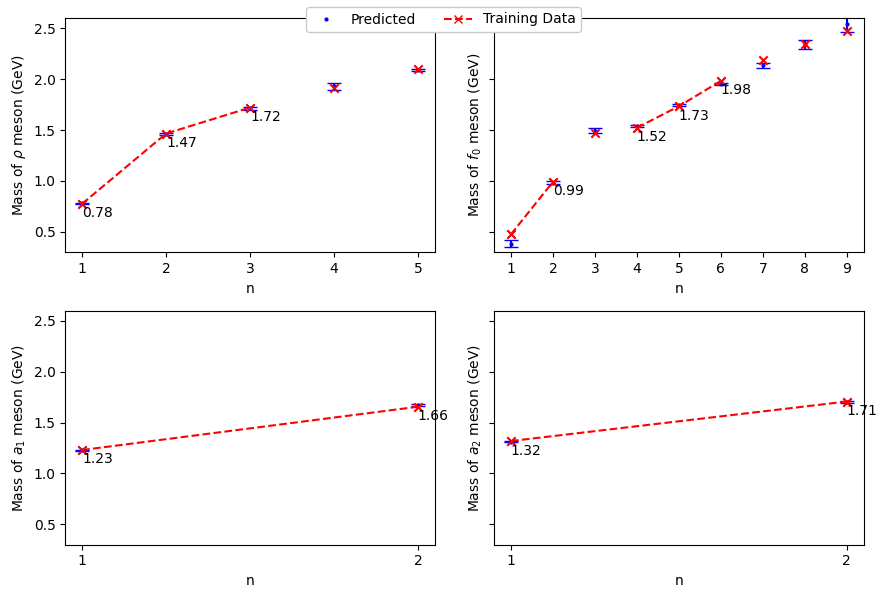

In [13]:
# plot the masses with error bars

# plot rho masses

fig, axs = plt.subplots(2, 2, figsize=(9, 6), sharey=True)
axs = axs.flatten()

line1 = axs[0].errorbar(range(1, len(rho_mass_array)+1), rho_mass_array[:,0], yerr=rho_mass_array[:,1], fmt='o', label='Predicted', capsize=5, zorder=0, markersize=2, color='b')
line2 = axs[0].plot(range(1, len(omega_rho)+1), omega_rho.cpu().numpy(), color='r', marker='x', linestyle='dashed', zorder=1)
for i in range(len(omega_rho)):
    axs[0].annotate(f"{omega_rho[i].item():.2f}", (i+1, omega_rho[i].item()-0.2), textcoords="offset points", xytext=(0,5), ha='left')
axs[0].set_xlabel("n")
axs[0].set_ylabel("Mass of $\\rho$ meson (GeV)")
axs[0].set_xticks(range(1, len(rho_mass_array)+1))
#axs[0].legend()
axs[0].set_ylim([0.3, 2.6])
rho_mass = [0.775, 1.465, 1.720, 1.909, 2.095]
axs[0].scatter(range(1, len(rho_mass)+1), rho_mass, color='red', marker='x', label='Experimental')

axs[1].errorbar(range(1, len(f0_mass_array)+1), f0_mass_array[:,0], yerr=f0_mass_array[:,1], fmt='o', label='Predicted', capsize=5, zorder=0, markersize=2, color='b')
axs[1].plot(range(1, len(omega_f0)+1), omega_f0.cpu().numpy(), color='r', marker='x', label='Experimental', linestyle='dashed', zorder=1)
for i in range(len(omega_f0)):
    axs[1].annotate(f"{omega_f0[i].item():.2f}", (i+1, omega_f0[i].item()-0.2), textcoords="offset points", xytext=(0,5), ha='left')
axs[1].set_xlabel("n")
axs[1].set_ylabel("Mass of $f_0$ meson (GeV)")
axs[1].set_xticks(range(1, len(f0_mass_array)+1))
f0_mass = [0.478, 0.990, 1.472, 1.522, 1.733, 1.982, 2.187, 2.340, 2.470]
axs[1].scatter(range(1, len(f0_mass)+1), f0_mass, color='red', marker='x', label='Experimental')



#axs[1].legend()

# plot a1 masses
axs[2].errorbar(range(1, len(a1_mass_array)+1), a1_mass_array[:,0], yerr=a1_mass_array[:,1], fmt='o', label='Predicted', capsize=5, zorder=0, markersize=2, color='b')
axs[2].plot(range(1, len(omega_a1)+1), omega_a1.cpu().numpy(), color='r', marker='x', label='Experimental', linestyle='dashed', zorder=1)
for i in range(len(omega_a1)):
    axs[2].annotate(f"{omega_a1[i].item():.2f}", (i+1, omega_a1[i].item()-0.2), textcoords="offset points", xytext=(0,5), ha='left')
axs[2].set_xlabel("n")
axs[2].set_ylabel("Mass of $a_1$ meson (GeV)")
axs[2].set_xticks(range(1, len(a1_mass_array)+1))
a1_mass = [1.230, 1.655]
axs[2].scatter(range(1, len(a1_mass)+1), a1_mass, color='red', marker='x', label='Experimental')
#axs[2].legend()

# plot a2 masses
axs[3].errorbar(range(1, len(a2_mass_array)+1), a2_mass_array[:,0], yerr=a2_mass_array[:,1], fmt='o', label='Predicted', capsize=5, zorder=0, markersize=2, color='b')
axs[3].plot(range(1, len(omega_a2)+1), omega_a2.cpu().numpy(), color='r', marker='x', label='Experimental', linestyle='dashed', zorder=1)
for i in range(len(omega_a2)):
    axs[3].annotate(f"{omega_a2[i].item():.2f}", (i+1, omega_a2[i].item()-0.2), textcoords="offset points", xytext=(0,5), ha='left')
axs[3].set_xlabel("n")
axs[3].set_ylabel("Mass of $a_2$ meson (GeV)")
axs[3].set_xticks(range(1, len(a2_mass_array)+1))
a2_mass = [1.318, 1.706]
axs[3].scatter(range(1, len(a2_mass)+1), a2_mass, color='red', marker='x', label='Experimental')
#axs[3].legend()

fig.legend([line1[0], line2[0]], ['Predicted', 'Training Data'], loc='upper center', ncols=2, framealpha=1)

plt.tight_layout()
plt.savefig('results/meson_masses.pdf')
plt.show()

In [8]:
z = torch.arange(z_ini, z_max, h, requires_grad=True)

v_list = []
A_list = []
dA_dz_list = []
d2A_dz2_list = []
dv_dz_list = []
d2v_dz2_list = []

for i in range(len(folder_numbers)):
    model_A = model_A_list[i]
    model_v = model_v_list[i]
    L = torch.tensor(L_list[i])
    theta = torch.tensor(theta_list[i])

    v_z = v_z_fn(z, model_v, theta, L)
    A_z = A_z_fn(z, model_A)
    
    dA_dz = autograd.grad(A_z, z, torch.ones_like(A_z), create_graph=True)[0]
    d2A_dz2 = autograd.grad(dA_dz, z, torch.ones_like(dA_dz), create_graph=True)[0]
    dv_dz = autograd.grad(v_z, z, torch.ones_like(v_z), create_graph=True)[0]
    d2v_dz2 = autograd.grad(dv_dz, z, torch.ones_like(dv_dz), create_graph=True)[0]

    v_list.append(v_z.cpu().detach().numpy())
    A_list.append(A_z_fn(z, model_A).cpu().detach().numpy())

    dA_dz_list.append(dA_dz.cpu().detach().numpy())
    d2A_dz2_list.append(d2A_dz2.cpu().detach().numpy())
    dv_dz_list.append(dv_dz.cpu().detach().numpy())
    d2v_dz2_list.append(d2v_dz2.cpu().detach().numpy())


v_list = np.array(v_list)
A_list = np.array(A_list)
dA_dz_list = np.array(dA_dz_list)
d2A_dz2_list = np.array(d2A_dz2_list)
dv_dz_list = np.array(dv_dz_list)
d2v_dz2_list = np.array(d2v_dz2_list)


In [9]:
dB2_dz_list = []
dphi_dz_list = []
phi_z_list = []
for i in range(len(folder_numbers)):
    exp_2A_z = np.exp(2*A_list[i])
    v_z = v_list[i]
    dv_dz = dv_dz_list[i]
    d2v_dz2 = d2v_dz2_list[i]
    k2 = k2_list[i]
    k1 = k1_list[i]

    dB2_dz = (d2v_dz2 - exp_2A_z*(-3*v_z - V_k_fn(torch.tensor(v_z), k1, k2).cpu().detach().numpy()))/dv_dz
    dphi_dz = dB2_dz + 3*dA_dz_list[i]
    dB2_dz_list.append(dB2_dz)
    dphi_dz_list.append(dphi_dz)

    # solve for phi_z using numerical integration
    phi_z = np.zeros_like(dphi_dz)
    phi_z[0] = 0.0 + dphi_dz[0]*h
    for j in range(1, len(phi_z)):
        phi_z[j] = phi_z[j-1] + dphi_dz[j]*h
    phi_z_list.append(phi_z)

dB2_dz_list = np.array(dB2_dz_list)
dphi_dz_list = np.array(dphi_dz_list)
phi_z_list = np.array(phi_z_list)

In [10]:
dz = 0.02
loss_pi_list = []
pi_masses_list = []
for i in range(len(folder_numbers)):
    z = torch.arange(dz, z_max, dz, requires_grad=True)

    k1 = torch.tensor(k1_list[i])
    k2 = torch.tensor(k2_list[i])
    L = torch.tensor(L_list[i])
    theta = torch.tensor(theta_list[i])
    model_A = model_A_list[i]
    model_v = model_v_list[i]

    v_z = v_z_fn(z, model_v, theta, L)
    dv_dz = autograd.grad(v_z, z, torch.ones_like(v_z), create_graph=True)[0]
    d2v_dz2 = autograd.grad(dv_dz, z, torch.ones_like(dv_dz), create_graph=True)[0]

    A_z = A_z_fn(z, model_A)
    exp_2A = torch.exp(2*A_z)
    dA_dz = autograd.grad(A_z, z, torch.ones_like(A_z), create_graph=True)[0]

    dB2_dz = B2_dash_z_fn(exp_2A, v_z, dv_dz, d2v_dz2, k1, k2)
    dB1_dz = dB2_dz + 2*dA_dz

    omega_z = 2*dv_dz/v_z - dB2_dz
    C_z = g5_sq*exp_2A*v_z**2

    # making M1 matrix
    diag_elem_M1 = -2/dz**2 * torch.ones_like(z)
    off_diag_elem_M1_plus = 1/dz**2 + omega_z[:-1]/(2*dz)
    off_diag_elem_M1_minus = 1/dz**2 - omega_z[1:]/(2*dz)
    M1 = torch.diag(diag_elem_M1) + torch.diag(off_diag_elem_M1_plus, diagonal=1) + torch.diag(off_diag_elem_M1_minus, diagonal=-1)

    M1[-1, -1] += 1/dz**2 + omega_z[-1]/(2*dz) # Neumann BC at IR

    # making M2 matrix
    M2 = torch.diag(C_z)

    # making M3 matrix
    diag_elem_M3 = -2/dz**2 - C_z
    off_diag_elem_M3_plus = 1/dz**2 - dB1_dz[:-1]/(2*dz)
    off_diag_elem_M3_minus = 1/dz**2 + dB1_dz[1:]/(2*dz)
    M3 = torch.diag(diag_elem_M3) + torch.diag(off_diag_elem_M3_plus, diagonal=1) + torch.diag(off_diag_elem_M3_minus, diagonal=-1)

    M3[-1, -1] += 1/dz**2 - dB1_dz[-1]/(2*dz) # Neumann BC IR

    M = torch.zeros((2*len(z), 2*len(z)), device=device)
    M[:len(z), :len(z)] = M1
    M[len(z):, :len(z)] = M2
    M[len(z):, len(z):] = M3

    # make T = [[-1, 1], [0, 0]]
    T = torch.zeros((2*len(z), 2*len(z)), device=device)
    T[:len(z), :len(z)] = -1*torch.eye(len(z))
    T[:len(z), len(z):] = torch.eye(len(z))

    M = M.cpu().detach().numpy()
    T = T.cpu().detach().numpy()

    # solve generalized eigenvalue problem using scipy
    eigenvalues_pi = scipy_eigvals(M, T)
    # sort eigenvalues
    eigenvalues_pi = np.sort(eigenvalues_pi.real)
    eigenvalues_pi = eigenvalues_pi[:len(omega_pi)]/(L_list[i]**2)
    pi_mass = np.sqrt(eigenvalues_pi)

    pi_masses_list.append(pi_mass)

    # Loss for each run
    loss_pi = ((np.abs(eigenvalues_pi - omega_pi.cpu().numpy()**2)/omega_pi.cpu().numpy()**2)).mean()
    loss_pi_list.append(loss_pi)

    #print(f"Run {i}: Pi Mass Loss = {loss_pi:.3f}")

best_pi_fit_index = np.argmin(loss_pi_list)
print(f"Best fit Run for Pi Mass: {best_pi_fit_index}")


Best fit Run for Pi Mass: 7


In [11]:
for i in range(len(folder_numbers)):
    print(f"Run {folder_numbers[i]}: Min Training Loss = {min_loss_list[i]:.2e}, Pi Mass Loss = {loss_pi_list[i]:.3f}, k1 = {k1_list[i]:.2f}, k2 = {k2_list[i]:.2f}, L = {L_list[i]:.2f}, theta = {theta_list[i]:.2f}")
    if min_loss_list[i] > 1e-2:
        print(f"  --> High loss value in folder {folder_numbers[i]}!")

# get index of minimum loss in ascending order
sorted_indices = np.argsort(loss_pi_list)
print(sorted_indices)

Run 0: Min Training Loss = 5.35e-03, Pi Mass Loss = 0.378, k1 = -4.01, k2 = 7.45, L = 1.23, theta = 4.53
Run 1: Min Training Loss = 6.42e-03, Pi Mass Loss = 0.359, k1 = -4.84, k2 = 9.59, L = 1.20, theta = 5.14
Run 2: Min Training Loss = 7.82e-03, Pi Mass Loss = 0.586, k1 = -3.51, k2 = 6.62, L = 1.60, theta = 5.11
Run 3: Min Training Loss = 7.38e-03, Pi Mass Loss = 0.400, k1 = -2.93, k2 = 6.04, L = 1.00, theta = 1.57
Run 4: Min Training Loss = 6.76e-03, Pi Mass Loss = 0.307, k1 = -2.54, k2 = 4.40, L = 1.00, theta = 4.10
Run 5: Min Training Loss = 8.16e-03, Pi Mass Loss = 0.575, k1 = -4.15, k2 = 7.98, L = 1.61, theta = 4.63
Run 6: Min Training Loss = 4.44e-03, Pi Mass Loss = 0.510, k1 = -5.13, k2 = 10.16, L = 1.39, theta = 4.56
Run 7: Min Training Loss = 4.94e-03, Pi Mass Loss = 0.305, k1 = -5.24, k2 = 10.75, L = 1.00, theta = 3.33
Run 8: Min Training Loss = 6.89e-03, Pi Mass Loss = 0.474, k1 = -5.29, k2 = 10.87, L = 1.31, theta = 2.12
Run 9: Min Training Loss = 4.72e-03, Pi Mass Loss = 


Pi Mass:
0.157 ± 0.017, Actual: 0.135, Best Fit: 0.137 %age error: 1.71%
1.720 ± 0.017, Actual: 1.300, Best Fit: 1.717 %age error: 32.11%
1.921 ± 0.023, Actual: 1.800, Best Fit: 1.918 %age error: 6.58%


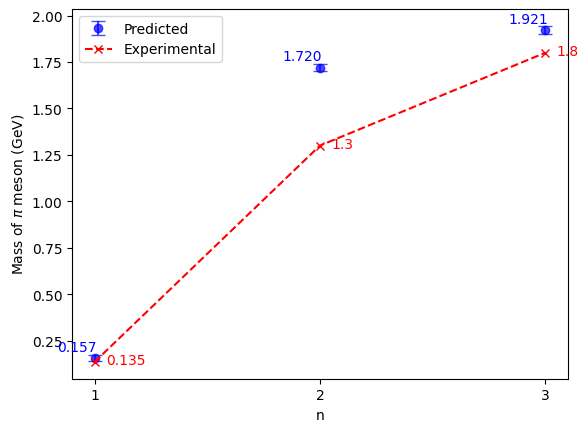

In [12]:
pi_mass_list = []

print("\nPi Mass:")
for i in range(len(omega_pi)):
    masses = [pi_masses_list[j][i] for j in range(len(pi_masses_list))]
    mass = np.mean(masses)
    std = np.std(masses)
    pi_mass_list.append([mass, std])
    print(f"{mass:.3f} ± {std:.3f}, Actual: {omega_pi[i]:.3f}, Best Fit: {pi_masses_list[best_pi_fit_index][i]:.3f} %age error: {abs(pi_masses_list[best_pi_fit_index][i] - omega_pi[i].item())/omega_pi[i].item()*100:.2f}%")

#pi_mass_list = [[np.nan, np.nan]] + pi_mass_list
#omega_pi_full = torch.concat((torch.tensor([0.134]), omega_pi))
omega_pi_full = omega_pi

line1 = plt.errorbar(range(1, len(omega_pi_full)+1), [pi_mass_list[i][0] for i in range(len(omega_pi_full))], yerr=[pi_mass_list[i][1] for i in range(len(omega_pi_full))], fmt='o', capsize=5, label='Predicted', zorder=2, alpha=0.7, color="blue")
line2, = plt.plot(range(1, 4), omega_pi_full.cpu().numpy(), 'x', label='Experimental', linestyle='dashed', color='red', zorder=3)
""" for i in range(len(folder_numbers)):
    line3 = plt.scatter(range(1, len(omega_pi_full)+1), pi_masses_list[i], color='black', marker='.', zorder=1, s=5) """
#line4, = plt.plot(range(1, len(omega_pi_full)+1), pi_masses_list[best_pi_fit_index], color='tab:orange', linestyle='dotted', label='Best Fit Run', zorder=4)
for i in range(len(omega_pi_full)):
    plt.annotate(f"{omega_pi_full[i].item()}", (i+1.05, omega_pi_full[i].item()-0.05), textcoords="offset points", xytext=(0,5), ha='left', color='red')
    plt.annotate(f"{pi_mass_list[i][0]:.3f}", (i+1+0.01, pi_mass_list[i][0]+0.0), textcoords="offset points", xytext=(0,5), ha='right', color='blue')
plt.xlabel('n')
plt.ylabel('Mass of $\\pi$ meson (GeV)')
plt.legend(handles=[line1, line2], labels=['Predicted', 'Experimental'] )
plt.xticks(range(1, len(omega_pi_full)+1))
plt.savefig('results/pi_masses.pdf')
plt.show()

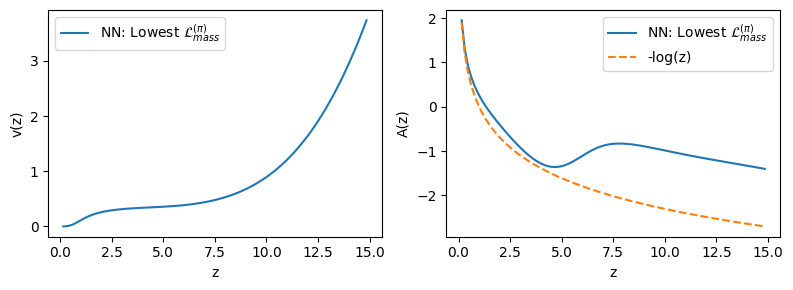

In [13]:
z = torch.arange(z_ini, z_max, h, requires_grad=True)
fig, axs = plt.subplots(1, 2, figsize=(8, 3))

axs[0].plot(z.cpu().detach().numpy(), v_list[best_pi_fit_index], label='NN: Lowest $\mathcal{L}_{mass}^{(\pi)}$')
axs[0].set_xlabel('z')
axs[0].set_ylabel('v(z)')
axs[0].legend()
axs[1].plot(z.cpu().detach().numpy(), A_list[best_pi_fit_index], label='NN: Lowest $\mathcal{L}_{mass}^{(\pi)}$')
axs[1].plot(z.cpu().detach().numpy(), -torch.log(z).cpu().detach().numpy(), label='-log(z)', linestyle='dashed')
axs[1].set_xlabel('z')
axs[1].set_ylabel('A(z)')
axs[1].legend()
plt.tight_layout()
plt.savefig('results/v_A_plots.pdf')
plt.show()

Linear-fit slope a = 3.1755
Quadratic-fit slope b = 0.2880


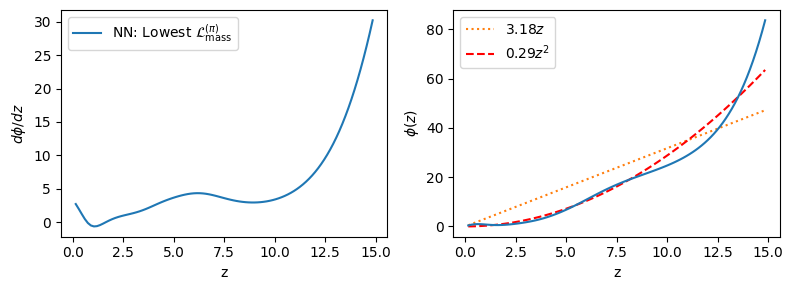

In [14]:
# Compute means and stds
z = torch.arange(z_ini, z_max, h)
dphi_dz_mean = np.mean(dphi_dz_list, axis=0)
dphi_dz_std = np.std(dphi_dz_list, axis=0)

phi_z_mean = np.mean(phi_z_list, axis=0)
phi_z_std = np.std(phi_z_list, axis=0)

# Convert z to numpy
z_np = z.cpu().detach().numpy()

# Perform linear fit: y = a*z
a, _, _, _ = np.linalg.lstsq(z_np[:, None], phi_z_list[best_pi_fit_index], rcond=None)
a = a[0]
print(f"Linear-fit slope a = {a:.4f}")

""" # Perform quadratic fit: y = b*z + c*z^2
# Construct design matrix for quadratic fit: [z, z^2]
X = np.column_stack([z_np, z_np**2])

# Solve least squares: y ≈ X @ [b, c]
params, _, _, _ = np.linalg.lstsq(X, phi_z_list[best_pi_fit_index], rcond=None)

b, c = params
print(f"Quadratic-fit parameters: b = {b:.6f}, c = {c:.6f}")
 """

# perform quadratic fit: y = b*z^2
b, _, _, _ = np.linalg.lstsq((z_np**2)[:, None], phi_z_list[best_pi_fit_index], rcond=None)
b = b[0]
print(f"Quadratic-fit slope b = {b:.4f}")

# Plot
fig, axs = plt.subplots(1, 2, figsize=(8, 3))

# --- dphi/dz plot ---
#axs[0].plot(z_np, dphi_dz_mean)
#axs[0].fill_between(z_np, dphi_dz_mean - dphi_dz_std, dphi_dz_mean + dphi_dz_std, alpha=0.3)
""" for i in range(len(folder_numbers)):
    line1, = axs[0].plot(z_np, dphi_dz_list[i], alpha=0.2, color='gray') """
line2, = axs[0].plot(z.cpu().detach().numpy(), dphi_dz_list[best_pi_fit_index], color='tab:blue', label="NN: Lowest $\mathcal{L}_{\\text{mass}}^{(\pi)}$")
axs[0].set_xlabel('z')
axs[0].set_ylabel('$d\phi/dz$')
#axs[0].set_ylim([-1, 13])
#axs[0].legend(handles=[line1, line2], labels=['NN: Individual Runs', 'NN: Lowest $\mathcal{L}_{\\text{mass}}^{(\\rho, a_1, a_2, f_0)}$'], loc='lower right')
axs[0].legend(handles=[line2], labels=['NN: Lowest $\mathcal{L}_{\\text{mass}}^{(\pi)}$'], loc='upper left')

# --- phi(z) plot ---

#axs[1].fill_between(z_np, phi_z_mean - phi_z_std, phi_z_mean + phi_z_std, alpha=0.3)
axs[1].plot(z_np, a*z_np, linestyle='dotted', label=f'${a:.2f} z$', color='tab:orange')
axs[1].plot(z_np, b*z_np**2, linestyle='dashed', label=f'${b:.2f} z^2$', color='red')
axs[1].plot(z.cpu().detach().numpy(), phi_z_list[best_pi_fit_index])
""" for i in range(len(folder_numbers)):
    axs[1].plot(z_np, phi_z_list[i], alpha=0.2, color='gray') """

axs[1].set_xlabel('z')
axs[1].set_ylabel('$\phi(z)$')
axs[1].legend(loc='upper left')
plt.tight_layout()
plt.savefig('results/phi_plot.pdf')
plt.show()


In [15]:
V_rho_list = []
V_a1_list = []
V_a2_list = []
V_f0_list = []
for i in range(len(folder_numbers)):
    model_A = model_A_list[i]
    model_v = model_v_list[i]
    k2 = k2_list[i]
    k1 = k1_list[i]
    L = torch.tensor(L_list[i])
    theta = torch.tensor(theta_list[i])

    exp_2A = torch.exp(2*A_z_fn(z, model_A))
    v_z = v_z_fn(z, model_v, theta, L)

    V_rho, V_a1, V_a2, V_f0 = V_mesons(model_A, model_v,  k1=k1, k2=k2, theta=theta, L=L)

    V_rho_list.append(V_rho.cpu().detach().numpy())
    V_a1_list.append(V_a1.cpu().detach().numpy())
    V_a2_list.append(V_a2.cpu().detach().numpy())
    V_f0_list.append(V_f0.cpu().detach().numpy())

V_rho_list = np.array(V_rho_list)
V_a1_list = np.array(V_a1_list)
V_a2_list = np.array(V_a2_list)
V_f0_list = np.array(V_f0_list)

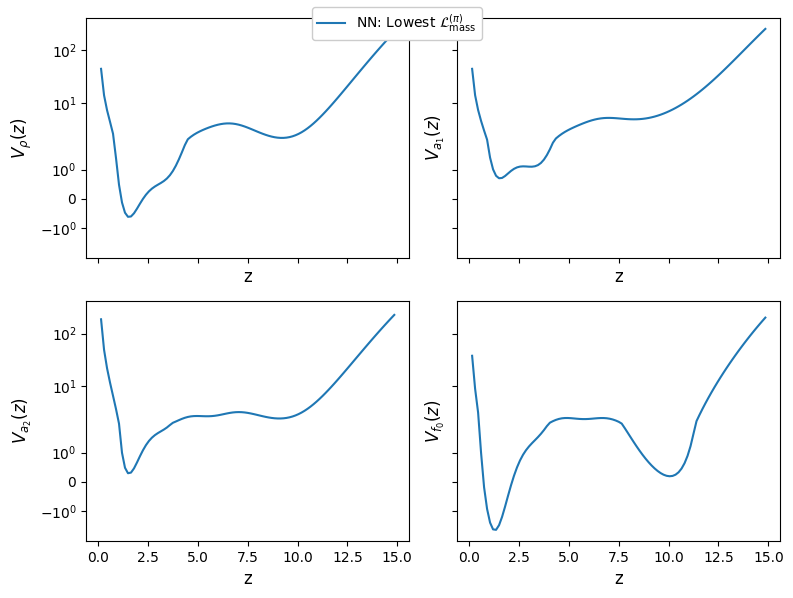

In [16]:
V_rho_mean = np.mean(V_rho_list, axis=0)
V_rho_std = np.std(V_rho_list, axis=0)

V_a1_mean = np.mean(V_a1_list, axis=0)
V_a1_std = np.std(V_a1_list, axis=0)

V_a2_mean = np.mean(V_a2_list, axis=0)
V_a2_std = np.std(V_a2_list, axis=0)

V_f0_mean = np.mean(V_f0_list, axis=0)
V_f0_std = np.std(V_f0_list, axis=0)

fig, axs = plt.subplots(2, 2, figsize=(8, 6), sharey=True, sharex=True)
axs = axs.flatten()
#axs[0].plot(z.cpu().detach().numpy(), V_rho_mean)
#axs[0].fill_between(z.cpu().detach().numpy(), V_rho_mean - V_rho_std, V_rho_mean + V_rho_std, alpha=0.3)
line1, = axs[0].plot(z.cpu().detach().numpy(), V_rho_list[best_pi_fit_index], color='tab:blue', label="NN: Lowest $\mathcal{L}_{\\text{mass}}^{(\\rho, a_1, a_2, f_0)}$")
""" for i in range(len(folder_numbers)):
    line2, = axs[0].plot(z.cpu().detach().numpy(), V_rho_list[i], alpha=0.2, color='gray') """
axs[0].set_ylabel('$V_\\rho(z)$', fontsize=12)

line1, = axs[1].plot(z.cpu().detach().numpy(), V_a1_list[best_pi_fit_index], color='tab:blue', label="NN: Lowest $\mathcal{L}_{\\text{mass}}^{(\\rho, a_1, a_2, f_0)}$")
""" for i in range(len(folder_numbers)):
    line2, = axs[1].plot(z.cpu().detach().numpy(), V_a1_list[i], alpha=0.2, color='gray') """
axs[1].set_ylabel('$V_{a_1}(z)$', fontsize=12)

line1, = axs[2].plot(z.cpu().detach().numpy(), V_a2_list[best_pi_fit_index], color='tab:blue', label="NN: Lowest $\mathcal{L}_{\\text{mass}}^{(\\rho, a_1, a_2, f_0)}$")
""" for i in range(len(folder_numbers)):
    line2, = axs[2].plot(z.cpu().detach().numpy(), V_a2_list[i], alpha=0.2, color='gray') """
axs[2].set_ylabel('$V_{a_2}(z)$', fontsize=12)

line1, = axs[3].plot(z.cpu().detach().numpy(), V_f0_list[best_pi_fit_index], color='tab:blue', label="NN: Lowest $\mathcal{L}_{\\text{mass}}^{(\\rho, a_1, a_2, f_0)}$")
""" for i in range(len(folder_numbers)):
    line2, = axs[3].plot(z.cpu().detach().numpy(), V_f0_list[i], alpha=0.2, color='gray') """
axs[3].set_ylabel('$V_{f_0}(z)$', fontsize=12)

fig.legend(handles=[line1], labels=['NN: Lowest $\mathcal{L}_{\\text{mass}}^{(\pi)}$'], ncols=2, loc='upper center', framealpha=1)

for ax in axs:
    ax.set_xlabel('z', fontsize=12)
    ax.set_yscale('symlog')

plt.tight_layout()
plt.savefig('results/potentials.pdf')
plt.show()

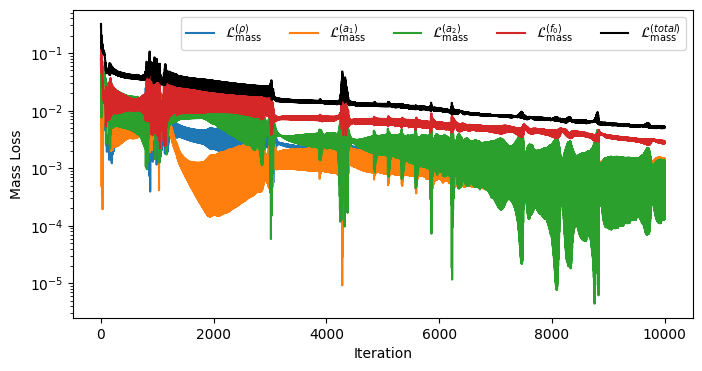

In [17]:
# get loss data of best fit
loss_data = pd.read_csv(folder_name + str(best_pi_fit_index) + '/' + 'mass_loss.csv')

loss_data = np.array(loss_data)

plt.figure(figsize=(8,4))
plt.plot(loss_data[:,0], label='$\mathcal{L}_{\\text{mass}}^{(\\rho)}$')
plt.plot(loss_data[:,1], label='$\mathcal{L}_{\\text{mass}}^{(a_1)}$')
plt.plot(loss_data[:,2], label='$\mathcal{L}_{\\text{mass}}^{(a_2)}$')
plt.plot(loss_data[:,3], label='$\mathcal{L}_{\\text{mass}}^{(f_0)}$')
plt.plot(np.sum(loss_data, axis=1), label='$\mathcal{L}_{\\text{mass}}^{(total)}$', color='black')
plt.xlabel('Iteration')
plt.ylabel('Mass Loss')
plt.yscale('log')
plt.legend(ncols=5)
plt.savefig('results/mass_loss.pdf')
plt.show()


In [18]:
print("Percentage errors for testing data:")
print(f"Rho 4: {100*np.abs(rho_mass_list[3,0] - 1.909)/1.909:.2f}%")
print(f"Rho 5: {100*np.abs(rho_mass_list[4,0] - 2.095)/2.095:.2f}%")

print(f"f0 3: {100*np.abs(f0_mass_list[2,0] - 1.472)/1.472:.2f}%")
print(f"f0 7: {100*np.abs(f0_mass_list[6,0] - 2.187)/2.187:.2f}%")
print(f"f0 8: {100*np.abs(f0_mass_list[7,0] - 2.340)/2.340:.2f}%")
print(f"f0 9: {100*np.abs(f0_mass_list[8,0] - 2.470)/2.470:.2f}%")

Percentage errors for testing data:
Rho 4: 1.04%
Rho 5: 0.41%
f0 3: 1.54%
f0 7: 2.40%
f0 8: 0.01%
f0 9: 2.77%
